In [ ]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    Layer
)

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras import backend as K

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
# ==========================================
# LOAD SST-5 DATASET
# ==========================================

dataset = load_dataset("SetFit/sst5")

train_df = pd.DataFrame(dataset["train"])
val_df = pd.DataFrame(dataset["validation"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())

Repo card metadata block was not found. Setting CardData to empty.


                                                text  label     label_text
0  a stirring , funny and finally transporting re...      4  very positive
1  apparently reassembled from the cutting-room f...      1       negative
2  they presume their audience wo n't sit still f...      1       negative
3  the entire movie is filled with deja vu moments .      2        neutral
4  this is a visually stunning rumination on love...      3       positive


In [ ]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(8544, 3)
(1101, 3)
(2210, 3)


In [ ]:
train_df.head()

,text,label,label_text
0,"a stirring , funny and finally transporting re...",4,very positive
1,apparently reassembled from the cutting-room f...,1,negative
2,they presume their audience wo n't sit still f...,1,negative
3,the entire movie is filled with deja vu moments .,2,neutral
4,this is a visually stunning rumination on love...,3,positive


In [ ]:
train_df.columns

Index(['text', 'label', 'label_text'], dtype='object')

In [ ]:
print(train_df.isnull().sum())

print(val_df.isnull().sum())

print(test_df.isnull().sum())

text          0
label         0
label_text    0
dtype: int64
text          0
label         0
label_text    0
dtype: int64
text          0
label         0
label_text    0
dtype: int64


In [ ]:
label_names = {
    0:"Very Negative",
    1:"Negative",
    2:"Neutral",
    3:"Positive",
    4:"Very Positive"
}

train_df["Sentiment"] = train_df["label"].map(label_names)

train_df["Sentiment"].value_counts()

,count
Sentiment,
Positive,2322
Negative,2218
Neutral,1624
Very Positive,1288
Very Negative,1092


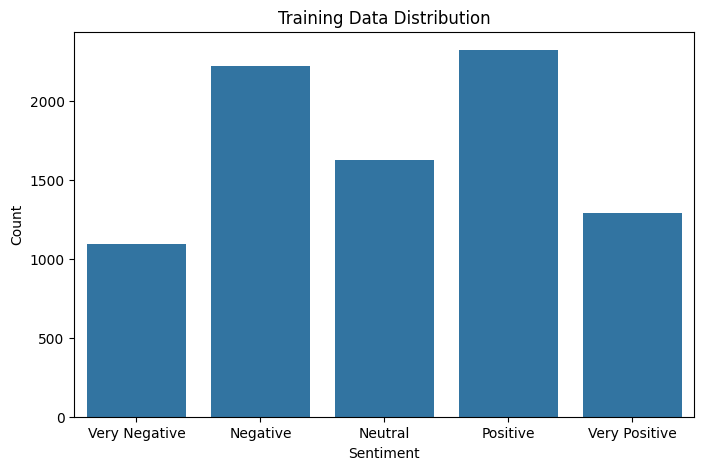

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train_df,
    x="Sentiment",
    order=[
        "Very Negative",
        "Negative",
        "Neutral",
        "Positive",
        "Very Positive"
    ]
)

plt.title("Training Data Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [ ]:
# ==========================================
# TEXT CLEANING FOR SST-5
# ==========================================

import re

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Expand contractions
    text = re.sub(r"can't", "can not", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'m", " am", text)

    # Remove extra spaces ONLY
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
train_df["clean_text"] = train_df["text"].apply(clean_text)

val_df["clean_text"] = val_df["text"].apply(clean_text)

test_df["clean_text"] = test_df["text"].apply(clean_text)

In [ ]:
train_df[["text","clean_text"]].head()

,text,clean_text
0,"a stirring , funny and finally transporting re...","a stirring , funny and finally transporting re..."
1,apparently reassembled from the cutting-room f...,apparently reassembled from the cutting-room f...
2,they presume their audience wo n't sit still f...,they presume their audience wo not sit still f...
3,the entire movie is filled with deja vu moments .,the entire movie is filled with deja vu moments .
4,this is a visually stunning rumination on love...,this is a visually stunning rumination on love...


In [ ]:
# ==========================================
# TOKENIZATION
# ==========================================

MAX_WORDS = 10000
MAX_LEN = 50

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(train_df["clean_text"])

In [ ]:
# Convert text to sequences

X_train = [list(filter(None, seq)) for seq in tokenizer.texts_to_sequences(train_df["clean_text"])]
X_val = [list(filter(None, seq)) for seq in tokenizer.texts_to_sequences(val_df["clean_text"])]
X_test = [list(filter(None, seq)) for seq in tokenizer.texts_to_sequences(test_df["clean_text"])]

In [ ]:
# Padding

X_train = pad_sequences(
    X_train,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val = pad_sequences(
    X_val,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

In [ ]:
!wget https://nlp.stanford.edu/data/glove.6B.zip

--2026-07-14 04:46:37--  https://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-07-14 04:46:37--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.1’

glove.6B.zip.1      100%[===================>] 822.24M  5.03MB/s    in 2m 43s  

2026-07-14 04:49:21 (5.04 MB/s) - ‘glove.6B.zip.1’ saved [862182613/862182613]



In [ ]:
!unzip glove.6B.zip

Archive:  glove.6B.zip
replace glove.6B.50d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       
  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       


In [ ]:
import numpy as np

EMBEDDING_DIM = 100

embeddings_index = {}

with open("glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

print("Loaded %s word vectors." % len(embeddings_index))

Loaded 400000 word vectors.


In [ ]:
word_index = tokenizer.word_index

num_words = min(MAX_WORDS, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))

for word, i in word_index.items():

    if i >= num_words:
        continue

    embedding_vector = embeddings_index.get(word)

    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (10000, 100)


In [ ]:
hits = 0
misses = 0

for word, i in word_index.items():

    if i >= num_words:
        continue

    if word in embeddings_index:
        hits += 1
    else:
        misses += 1

print("Words covered by GloVe:", hits)
print("Words not found:", misses)
print("Coverage: {:.2f}%".format(hits/(hits+misses)*100))

Words covered by GloVe: 9908
Words not found: 91
Coverage: 99.09%


In [ ]:
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    Layer,
    SpatialDropout1D
)

In [ ]:
# Labels

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

In [ ]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(8544, 50)
(1101, 50)
(2210, 50)


In [ ]:
# ==========================================
#  ATTENTION LAYER
# ==========================================

import tensorflow as tf
from tensorflow.keras.layers import Layer

class AttentionLayer(Layer):

    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):

        self.W = self.add_weight(
            shape=(input_shape[-1], input_shape[-1]),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            shape=(input_shape[-1],),
            initializer="zeros",
            trainable=True
        )

        self.u = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )

        super().build(input_shape)

    def call(self, inputs):

        score = tf.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)

        attention = tf.nn.softmax(
            tf.tensordot(score, self.u, axes=1),
            axis=1
        )

        context = tf.reduce_sum(inputs * attention, axis=1)

        return context

In [ ]:
# ==========================================
# IMPROVED BiLSTM-ATTENTION MODEL
# ==========================================

from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

inputs = Input(shape=(MAX_LEN,))

embedding = Embedding(
    input_dim=num_words,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=True
)(inputs)

x = SpatialDropout1D(0.3)(embedding)

x = Bidirectional(
    LSTM(
        128,
        return_sequences=True,
        dropout=0.5,
        recurrent_dropout=0.5,
        kernel_regularizer=l2(1e-4)
    )
)(x)

x = AttentionLayer()(x)

x = Dense(
    64,
    activation="relu",
    kernel_regularizer=l2(1e-4)
)(x)

x = Dropout(0.5)(x)

outputs = Dense(
    5,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 50, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 50, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 50, 256)        │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_3               │ (None, 256)            │        66,048 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,317 (5.03 MB)

 Trainable params: 1,317,317 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
checkpoint = ModelCheckpoint(

    "best_bilstm_attention.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1

)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    verbose=1

)

In [ ]:
# ==========================================
# TRAIN MODEL
# ==========================================

history = model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=30,

    batch_size=32,

    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ],

    verbose=1

)

Epoch 1/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.2471 - loss: 1.6304
Epoch 1: val_loss improved from None to 1.59934, saving model to best_bilstm_attention.keras

Epoch 1: finished saving model to best_bilstm_attention.keras
267/267 ━━━━━━━━━━━━━━━━━━━━ 73s 247ms/step - accuracy: 0.2570 - loss: 1.6208 - val_accuracy: 0.2534 - val_loss: 1.5993 - learning_rate: 5.0000e-04
Epoch 2/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.2727 - loss: 1.6024
Epoch 2: val_loss improved from 1.59934 to 1.48743, saving model to best_bilstm_attention.keras

Epoch 2: finished saving model to best_bilstm_attention.keras
267/267 ━━━━━━━━━━━━━━━━━━━━ 65s 243ms/step - accuracy: 0.2948 - loss: 1.5860 - val_accuracy: 0.3633 - val_loss: 1.4874 - learning_rate: 5.0000e-04
Epoch 3/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.3408 - loss: 1.5349
Epoch 3: val_loss improved from 1.48743 to 1.44503, saving model to best_bilstm_attention.keras

Epoch 3: finished saving mod

In [ ]:
model.load_weights("best_bilstm_attention.keras")

In [ ]:
# ==========================================
# LOAD BEST MODEL
# ==========================================

model.load_weights("best_bilstm_attention.keras")

In [ ]:
# ==========================================
# PREDICT TEST SET
# ==========================================

import numpy as np

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step


In [ ]:
# ==========================================
# EVALUATION METRICS
# ==========================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.4679
Precision: 0.4974
Recall   : 0.4679
F1 Score : 0.4224


In [ ]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

from sklearn.metrics import classification_report

label_names = [
    "Very Negative",
    "Negative",
    "Neutral",
    "Positive",
    "Very Positive"
]

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_names
    )
)

               precision    recall  f1-score   support

Very Negative       0.58      0.13      0.21       279
     Negative       0.47      0.80      0.59       633
      Neutral       0.41      0.11      0.17       389
     Positive       0.41      0.60      0.48       510
Very Positive       0.69      0.36      0.47       399

     accuracy                           0.47      2210
    macro avg       0.51      0.40      0.39      2210
 weighted avg       0.50      0.47      0.42      2210



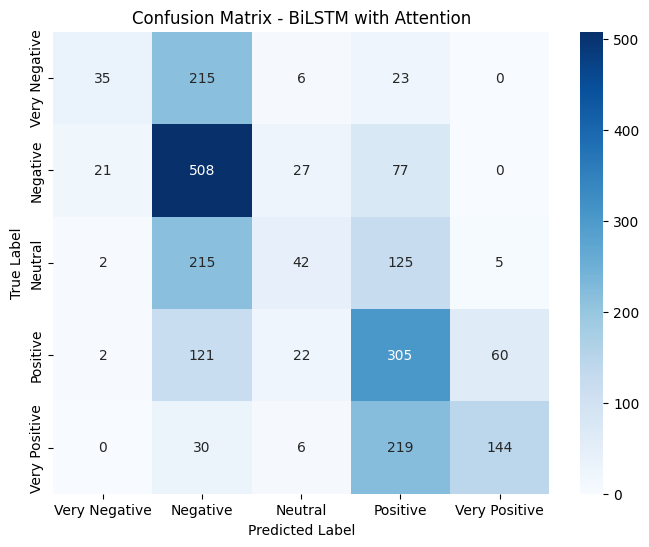

In [ ]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BiLSTM with Attention")

plt.show()

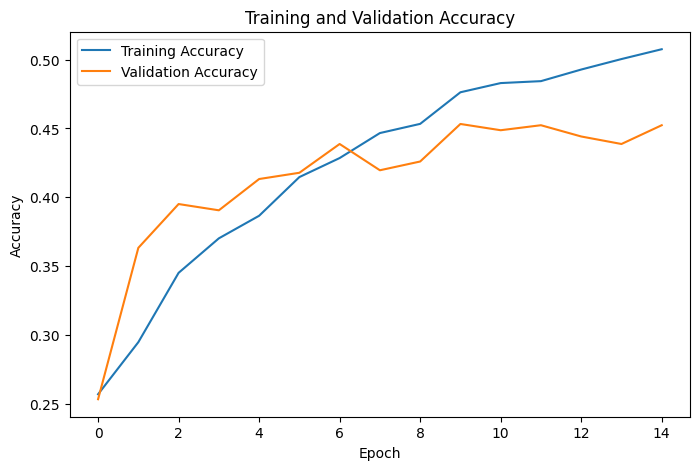

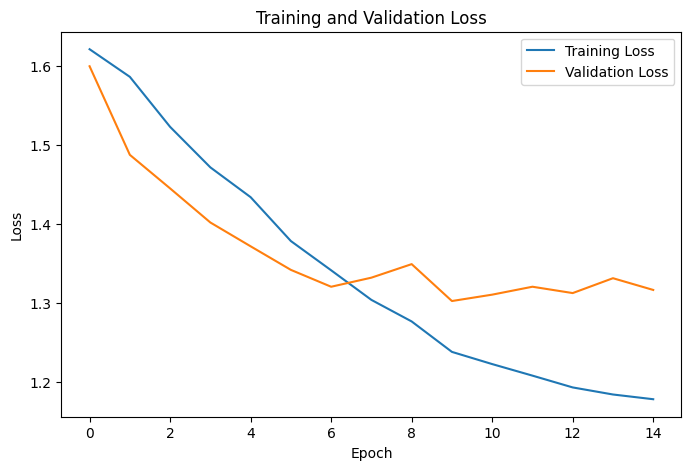

In [ ]:
# ==========================================
# TRAINING HISTORY
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()

plt.show()


plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()

plt.show()

In [ ]:
model.load_weights("best_bilstm_attention.keras")

In [ ]:
import tensorflow as tf

# Create the converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Enable default optimizations (if desired)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Fix for 'tf.TensorListReserve' error: Enable Select TF Ops and disable experimental tensor list lowering
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS  # Enable TF ops for unsupported operations
]
converter._experimental_lower_tensor_list_ops = False # Disable experimental lowering for tensor lists

# Convert the model
tflite_model = converter.convert()

# Save the model
with open("bilstm_attention_sst5.tflite", "wb") as f:
    f.write(tflite_model)

print("TensorFlow Lite model saved successfully!")

Saved artifact at '/tmp/tmpsqybt32z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50), dtype=tf.float32, name='keras_tensor_23')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134927350616080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317317008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317316432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317318928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317317584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317316240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317319312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317319504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317317968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317317200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317318352: Ten

In [ ]:
import os

keras_size = os.path.getsize("best_bilstm_attention.keras") / (1024 * 1024)
tflite_size = os.path.getsize("bilstm_attention_sst5.tflite") / (1024 * 1024)

print(f"Keras Model Size : {keras_size:.2f} MB")
print(f"TFLite Model Size: {tflite_size:.2f} MB")

reduction = ((keras_size - tflite_size) / keras_size) * 100
print(f"Size Reduction   : {reduction:.2f}%")

Keras Model Size : 15.13 MB
TFLite Model Size: 1.33 MB
Size Reduction   : 91.23%


In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

Saved artifact at '/tmp/tmpdipnl42j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50), dtype=tf.float32, name='keras_tensor_23')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134927350616080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317317008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317316432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317318928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317317584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317316240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317319312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317319504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317317968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317317200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134927317318352: Ten

In [ ]:
import pandas as pd

# Create a DataFrame of predictions
errors = pd.DataFrame({
    "Review": test_df["clean_text"],
    "Actual": y_test,
    "Predicted": y_pred
})

# Keep only incorrect predictions
misclassified = errors[errors["Actual"] != errors["Predicted"]]

print("Number of misclassified reviews:", len(misclassified))

# Display the first 20 errors
misclassified.head(20)

Number of misclassified reviews: 1176


,Review,Actual,Predicted
1,"a gob of drivel so sickly sweet , even the eag...",0,1
2,` how many more voyages can this limping but d...,2,1
3,so relentlessly wholesome it made me want to s...,2,3
5,"we never really feel involved with the story ,...",0,1
7,take care of my cat offers a refreshingly diff...,3,4
11,"a reasonably efficient mechanism , but it offe...",2,3
12,if this holiday movie is supposed to be a gift...,0,1
13,"jason x has cheesy effects and a hoary plot , ...",3,1
14,"even as lame horror flicks go , this is lame .",1,0
16,though the violence is far less sadistic than ...,4,1


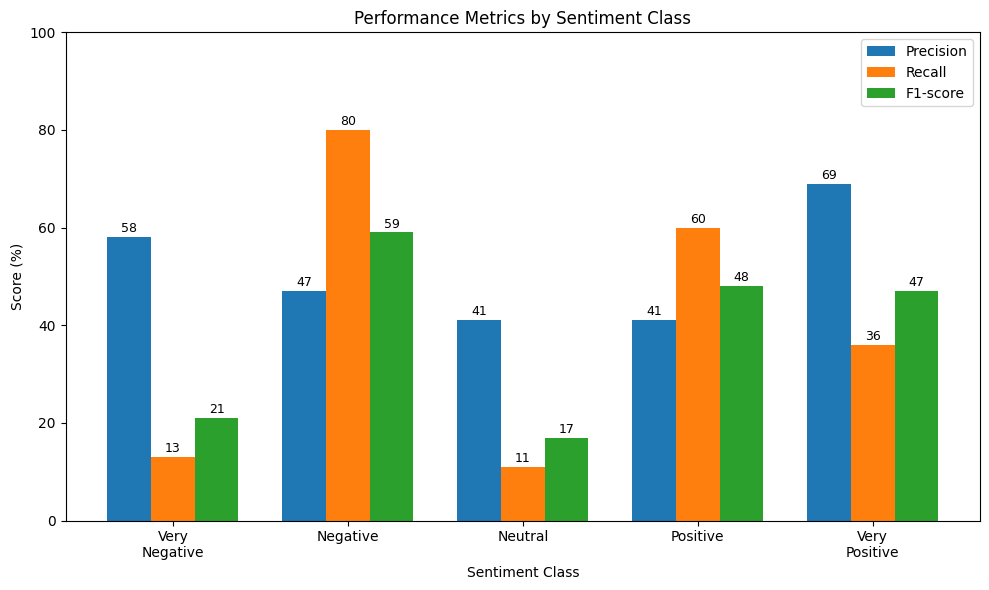

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sentiment classes
classes = [
    "Very\nNegative",
    "Negative",
    "Neutral",
    "Positive",
    "Very\nPositive"
]

# Performance metrics (%)
precision = [58, 47, 41, 41, 69]
recall    = [13, 80, 11, 60, 36]
f1_score  = [21, 59, 17, 48, 47]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width, precision, width, label="Precision")
bars2 = plt.bar(x, recall, width, label="Recall")
bars3 = plt.bar(x + width, f1_score, width, label="F1-score")

# Add values above bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{bar.get_height():.0f}",
            ha="center",
            fontsize=9
        )

plt.xlabel("Sentiment Class")
plt.ylabel("Score (%)")
plt.title("Performance Metrics by Sentiment Class")
plt.xticks(x, classes)
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.savefig("performance_metrics_by_class.png", dpi=300)
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Confusion matrix
cm = np.array([
    [35, 215,   6,  23,   0],
    [21, 508,  27,  77,   0],
    [ 2, 215,  42, 125,   5],
    [ 2, 121,  22, 305,  60],
    [ 0,  30,   6, 219, 144]
])

labels = [
    "Very Negative",
    "Negative",
    "Neutral",
    "Positive",
    "Very Positive"
]

errors = []

for actual in range(len(labels)):
    for predicted in range(len(labels)):
        if actual != predicted:
            errors.append({
                "Actual Class": labels[actual],
                "Predicted Class": labels[predicted],
                "Error Category": f"{actual} → {predicted}",
                "Number of Errors": cm[actual, predicted]
            })

error_df = pd.DataFrame(errors)

# Sort by highest number of errors
error_df = error_df.sort_values(
    by="Number of Errors",
    ascending=False
)

print(error_df)

     Actual Class Predicted Class Error Category  Number of Errors
19  Very Positive        Positive          4 → 3               219
0   Very Negative        Negative          0 → 1               215
9         Neutral        Negative          2 → 1               215
10        Neutral        Positive          2 → 3               125
13       Positive        Negative          3 → 1               121
6        Negative        Positive          1 → 3                77
15       Positive   Very Positive          3 → 4                60
17  Very Positive        Negative          4 → 1                30
5        Negative         Neutral          1 → 2                27
2   Very Negative        Positive          0 → 3                23
14       Positive         Neutral          3 → 2                22
4        Negative   Very Negative          1 → 0                21
18  Very Positive         Neutral          4 → 2                 6
1   Very Negative         Neutral          0 → 2              